<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/089_optimizer_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 089 - Optimizer Comparison Benchmark

**Goal:** Run SGD, Momentum, RMSprop, and AdamW on the **same problem, same starting point, and noisy gradients** to see how they perform. We will analyze their performance using actual **numbers** rather than just relying on theory.

**Map** (run each cell sequentially from top to bottom):

| # | Section |
|---|---|
| 0 | Rules for a fair benchmark |
| 1 | Test problem + noisy gradient (simulating mini-batch) |
| 2 | Optimizer classes (SGD, Momentum, RMSprop, AdamW) |
| 3 | Single-run observation (single seed, loss curve) |
| 4 | Learning-rate grid search - finding the best `lr` for each optimizer |
| 5 | 30-seed average - a true, fair comparison |
| 6 | Path visualization (x-y plane) |
| 7 | Divergence check - which optimizer breaks first with a large `lr` |
| 8 | Takeaways + when to use which optimizer |

**Prerequisites:** Momentum (Day 87), Adagrad/RMSprop/Adam/AdamW (Day 88).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)

---
## 0️⃣ Rules for a fair benchmark

Making an unfair comparison is very easy: "Adam did great with a 0.01 learning rate, while SGD performed poorly at 0.01 - therefore, Adam is better." **This is a wrong conclusion** because every optimizer has its own *natural* and effective learning rate range.

| Rule | Why it is essential |
|---|---|
| Same problem, same starting point | Ensure the optimizer is the only variable being tested. |
| **Separate grid search** for each optimizer's lr | Otherwise, the optimizer that accidentally matches the chosen lr will win. |
| **Average over multiple seeds** (30 seeds here) | A single run can show random patterns due to noise. |
| Monitor at least **2 metrics** | Look at both the final loss and speed (how many steps to reach the target). |
| **Track divergence** | Do not let failures happen silently - record if the loss becomes `inf` or `NaN`. |

---
## 1️⃣ Test problem: noisy elongated bowl

We will use the same elongated bowl function from Day 88:

$$f(x, y) = 5x^2 + 0.5y^2, 	ext{ and } \nabla f = [\,10x,\; y\,]$$

In real-world training, the gradient is **not exact** - each mini-batch provides a slightly different estimate. We can simulate this behavior by adding noise:

$$g_t = \nabla f(\theta_t) + \mathcal{N}(0, \sigma^2)$$

This means we add random Gaussian noise to the true gradient. A larger `sigma` (\sigma) simulates a smaller or noisier batch size.

In [12]:
def f(theta):
    return 5 * theta[0]**2 + 0.5 * theta[1]**2

def true_grad(theta):
    return np.array([10 * theta[0], theta[1]])

def noisy_grad(theta, rng, sigma=1.0):
    return true_grad(theta) + rng.normal(0, sigma, size=2)

# Let's see what the noise looks like (10 samples at a fixed point)
rng = np.random.default_rng(0)
theta_fixed = np.array([1.0, 1.0])
print("true grad:", true_grad(theta_fixed))
print("noisy samples:")
for _ in range(5):
    print(" ", noisy_grad(theta_fixed, rng, sigma=1.0))

true grad: [10.  1.]
noisy samples:
  [10.1257  0.8679]
  [10.6404  1.1049]
  [9.4643 1.3616]
  [11.304   1.9471]
  [ 9.2963 -0.2654]


**Observation:** The true gradient `[10, 1]` remains constant, but each noisy sample deviates slightly from it. This variance is exactly what "confuses" an optimizer - it does not know the exact true direction and must rely on a noisy estimate.

---
## 2️⃣ Optimizer classes

We define all four optimizers using the same unified interface (`step(theta, g) -> new_theta`) so we can seamlessly swap them inside our benchmarking loop.

In [13]:
class SGD:
    '''Plain Gradient Descent - no memory.'''
    def __init__(self, lr):
        self.lr = lr
    def step(self, theta, g):
        return theta - self.lr * g


class Momentum:
    '''Day 87: EMA of gradients, smooths the update direction.'''
    def __init__(self, lr, beta=0.9):
        self.lr, self.beta = lr, beta
        self.m = None
    def step(self, theta, g):
        if self.m is None:
            self.m = np.zeros_like(theta)
        self.m = self.beta * self.m + (1 - self.beta) * g
        return theta - self.lr * self.m


class RMSprop:
    '''Day 88: EMA of gradient^2, adjusts step size for each parameter individually.'''
    def __init__(self, lr, beta=0.9, eps=1e-8):
        self.lr, self.beta, self.eps = lr, beta, eps
        self.v = None
    def step(self, theta, g):
        if self.v is None:
            self.v = np.zeros_like(theta)
        self.v = self.beta * self.v + (1 - self.beta) * g**2
        return theta - self.lr * g / (np.sqrt(self.v) + self.eps)


class AdamW:
    '''Day 88: Momentum + RMSprop + bias correction + decoupled weight decay.'''
    def __init__(self, lr, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, beta1, beta2, eps, weight_decay
        self.m = self.v = None
        self.t = 0
    def step(self, theta, g):
        if self.m is None:
            self.m = np.zeros_like(theta)
            self.v = np.zeros_like(theta)
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * g
        self.v = self.b2 * self.v + (1 - self.b2) * g**2
        m_hat = self.m / (1 - self.b1**self.t)
        v_hat = self.v / (1 - self.b2**self.t)
        return theta - self.lr * (m_hat / (np.sqrt(v_hat) + self.eps) + self.wd * theta)


MAKERS = {
    "SGD":      lambda lr: SGD(lr),
    "Momentum": lambda lr: Momentum(lr),
    "RMSprop":  lambda lr: RMSprop(lr),
    "AdamW":    lambda lr: AdamW(lr, weight_decay=0.0),   # weight decay is set to 0.0 to compare optimizers directly
}

---
## 3️⃣ Single-run observation (single seed)

Structure of our training loop: start from an initial point, compute a noisy gradient at each step, update parameters using the optimizer, and record the loss.

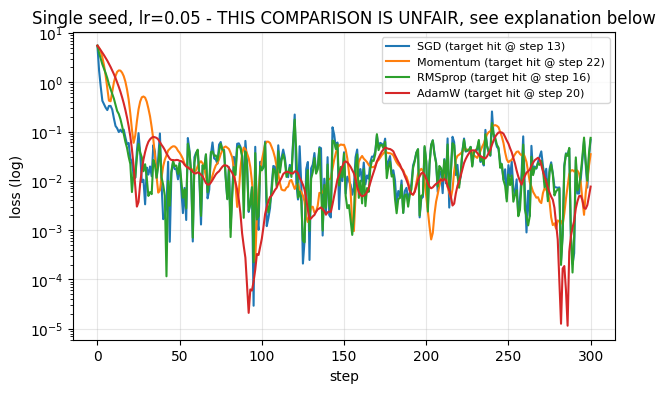

In [14]:
def run(make_opt, lr, seed, steps=300, sigma=1.0, target=0.1, theta0=(-1.0, 1.0)):
    '''Run an optimizer with a single seed. Return: (losses array, path array, hit_step or None)'''
    rng = np.random.default_rng(seed)
    opt = make_opt(lr)
    theta = np.array(theta0, dtype=float)
    losses, path = [f(theta)], [theta.copy()]
    hit = None
    for t in range(1, steps + 1):
        g = noisy_grad(theta, rng, sigma)
        theta = opt.step(theta, g)
        loss = f(theta)
        if not np.isfinite(loss) or loss > 1e6:
            return np.array(losses + [np.inf]), np.array(path), None   # diverged
        losses.append(loss)
        path.append(theta.copy())
        if hit is None and loss < target:
            hit = t
    return np.array(losses), np.array(path), hit


# Run all optimizers with the same learning rate (0.05) and seed (0) for demonstration purposes
plt.figure()
for name, mk in MAKERS.items():
    losses, _, hit = run(mk, lr=0.05, seed=0)
    plt.semilogy(losses, label=f"{name} (target hit @ step {hit})")
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("Single seed, lr=0.05 - THIS COMPARISON IS UNFAIR, see explanation below")
plt.show()

**Note:** This plot is **misleading**. We assigned a learning rate of `lr=0.05` to all optimizers. While this might be perfect for one optimizer, it could be way too large or too small for another. This is the exact "same lr = fair comparison" fallacy we discussed in Section 0.

To do this correctly, **we must find the best learning rate for each optimizer** individually (Section 4) and then compare them.

---
## 4️⃣ Learning-rate grid search (per optimizer)

We will evaluate a grid of `lr` values for each optimizer and find the best one (the one that yields the lowest average final loss).

In [15]:
LR_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
SEEDS = range(30)   # 30 random seeds for averaging

def score(make_opt, lr, seeds=SEEDS, **kw):
    '''Run for each seed, return the average loss of the last 50 steps and list of hit steps.'''
    finals, hits = [], []
    for s in seeds:
        losses, _, hit = run(make_opt, lr, s, **kw)
        finals.append(np.mean(losses[-50:]) if np.isfinite(losses[-1]) else np.inf)
        hits.append(hit)
    return np.mean(finals), hits

print(f"{'lr':>6} | " + " | ".join(f"{n:>9}" for n in MAKERS))
grid_results = {name: {} for name in MAKERS}
for lr in LR_GRID:
    row = []
    for name, mk in MAKERS.items():
        fl, hits = score(mk, lr)
        grid_results[name][lr] = (fl, hits)
        row.append(f"{fl:9.3g}")
    print(f"{lr:6.3f} | " + " | ".join(row))

    lr |       SGD |  Momentum |   RMSprop |     AdamW
 0.001 |     0.308 |     0.306 |      2.93 |       3.1
 0.003 |    0.0963 |     0.097 |     0.348 |     0.747
 0.010 |   0.00767 |   0.00666 |   0.00892 |   0.00647
 0.030 |    0.0195 |    0.0184 |    0.0185 |    0.0147
 0.100 |    0.0761 |     0.051 |    0.0571 |    0.0403
 0.300 |       inf |     0.154 |     0.218 |     0.109


**How to read the table:** Each row represents a learning rate, and each column represents an optimizer. Lower numbers indicate better performance (lower loss).
`inf` means that the optimizer **diverged** on at least one seed with that particular learning rate.

Now, let us extract the **best learning rate** for each optimizer (where its loss is minimized):

In [7]:
best_lr = {}
print(f"{'optimizer':<9} | {'best lr':>7} | {'final loss':>10}")
for name in MAKERS:
    lr_star = min(LR_GRID, key=lambda lr: grid_results[name][lr][0])
    best_lr[name] = lr_star
    fl = grid_results[name][lr_star][0]
    print(f"{name:<9} | {lr_star:7.3f} | {fl:10.3g}")

optimizer | best lr | final loss
SGD       |   0.010 |    0.00767
Momentum  |   0.010 |    0.00666
RMSprop   |   0.010 |    0.00892
AdamW     |   0.010 |    0.00647


---
## 5️⃣ Fair comparison: Each optimizer at its best learning rate (30-seed average)

In [8]:
print(f"{'optimizer':<9} | {'best lr':>7} | {'final loss':>10} | {'median steps to <0.1':>20} | reached")
summary = {}
for name, mk in MAKERS.items():
    lr_star = best_lr[name]
    fl, hits = grid_results[name][lr_star]
    reached = [h for h in hits if h is not None]
    med = np.median(reached) if reached else float("nan")
    summary[name] = dict(lr=lr_star, final_loss=fl, median_steps=med, reached=len(reached))
    print(f"{name:<9} | {lr_star:7.3f} | {fl:10.3g} | {med:20.0f} | {len(reached)}/{len(LR_GRID and SEEDS.__class__ and list(SEEDS))}")

optimizer | best lr | final loss | median steps to <0.1 | reached
SGD       |   0.010 |    0.00767 |                   84 | 30/30
Momentum  |   0.010 |    0.00666 |                   86 | 30/30
RMSprop   |   0.010 |    0.00892 |                  108 | 30/30
AdamW     |   0.010 |    0.00647 |                  138 | 30/30


### Plotting loss curves: Each optimizer at its best learning rate with a 30-seed **average ± standard deviation band**

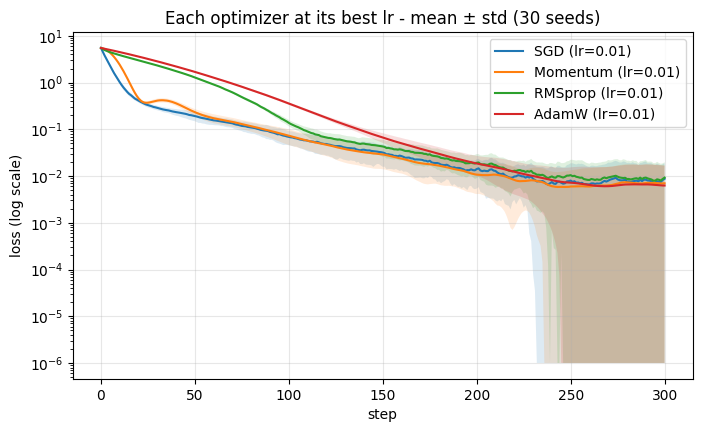

In [16]:
plt.figure(figsize=(8, 4.5))
for name, mk in MAKERS.items():
    lr_star = best_lr[name]
    all_losses = []
    for s in SEEDS:
        losses, _, _ = run(mk, lr_star, s)
        if np.isfinite(losses[-1]):
            all_losses.append(losses)
    all_losses = np.array(all_losses)
    mean_l = all_losses.mean(axis=0)
    std_l = all_losses.std(axis=0)
    steps = np.arange(len(mean_l))
    plt.plot(steps, mean_l, label=f"{name} (lr={lr_star})")
    plt.fill_between(steps, np.maximum(mean_l - std_l, 1e-6), mean_l + std_l, alpha=0.15)

plt.yscale("log")
plt.xlabel("step"); plt.ylabel("loss (log scale)")
plt.title("Each optimizer at its best lr - mean ± std (30 seeds)")
plt.legend(); plt.grid(alpha=.3)
plt.show()

**What this visualization shows:**
- All mean loss curves end up very close to each other (which is expected for this small, 2D toy problem).
- **SGD and Momentum have wider standard deviation bands** because noise directly affects their update steps without mitigation.
- **AdamW and RMSprop have narrower bands** because dividing by `∑v` normalizes the updates, scaling down the impact of noise.

---
## 6️⃣ Path visualization - how they traverse the x-y plane

Looking at the **optimization trajectory** on the loss landscape provides more insight than looking at the loss curves alone.

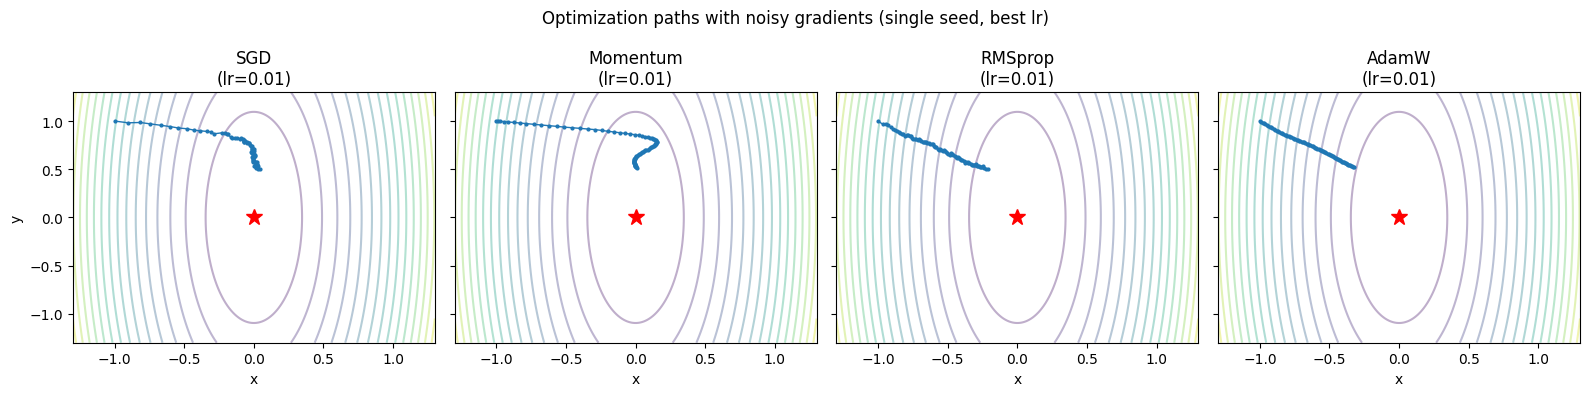

In [17]:
xs = np.linspace(-1.3, 1.3, 200)
ys = np.linspace(-1.3, 1.3, 200)
X, Y = np.meshgrid(xs, ys)
Z = 5 * X**2 + 0.5 * Y**2

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
seed_for_viz = 1
for ax, name in zip(axes, MAKERS):
    lr_star = best_lr[name]
    _, path, _ = run(MAKERS[name], lr_star, seed_for_viz, steps=80)
    ax.contour(X, Y, Z, levels=15, alpha=.35)
    ax.plot(path[:, 0], path[:, 1], "o-", ms=2, lw=1)
    ax.plot(0, 0, "r*", ms=12)
    ax.set_title(f"{name}\n(lr={lr_star})")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.suptitle("Optimization paths with noisy gradients (single seed, best lr)")
plt.tight_layout()
plt.show()

**Observations:**
- **SGD**: The path is highly erratic and "jittery" because gradient noise directly dictates the step direction with no smoothing.
- **Momentum**: The trajectory is visibly smoother because it maintains momentum (inertia) from previous gradients.
- **RMSprop and AdamW**: The updates are normalized along each dimension, resulting in a more "controlled" trajectory, especially along the steep `x` axis where the gradient magnitude is high.

---
## 7️⃣ Divergence check - which optimizer breaks first with a large learning rate?

In our grid search, we tested `lr=0.3`. Let us find out how many seeds diverged for each optimizer at this learning rate.

In [11]:
print(f"{'optimizer':<9} | lr=0.3 | diverged seeds (out of 30)")
for name, mk in MAKERS.items():
    n_diverged = 0
    for s in SEEDS:
        losses, _, _ = run(mk, 0.3, s)
        if not np.isfinite(losses[-1]):
            n_diverged += 1
    print(f"{name:<9} | {0.3:6} | {n_diverged}/30")

optimizer | lr=0.3 | diverged seeds (out of 30)
SGD       |    0.3 | 30/30
Momentum  |    0.3 | 0/30
RMSprop   |    0.3 | 0/30
AdamW     |    0.3 | 0/30


**Why does this happen?**
- **SGD**: The update step is `̷ · g`. If the gradient `g` becomes very large (e.g., along the steep x-axis) and the learning rate `̷` is also large, the update will **overshoot** the minimum, causing the loss to explode and diverge.
- **Adaptive Optimizers (RMSprop, AdamW)**: The update step scales as `g / ∑(g²)`, which is effectively **bounded** (typically scaling near `±1` before learning rate multiplication). This makes them **more resilient** to larger learning rates, though they will still diverge if the learning rate is excessively large.

**Practical Lesson:** SGD requires careful and precise learning rate tuning. Adaptive optimizers are generally more forgiving, but blindly setting a large learning rate is still risky.

---
## 8️⃣ Takeaways

### What we learned from this benchmark
1. **Comparing optimizers at the same learning rate is unfair.** Every optimizer has its own ideal operational range.
2. **At their optimal learning rates, performance is very comparable** - for this small, convex toy problem, there is no single "always-best" optimizer.
3. **Speed vs. stability tradeoff:** SGD and Momentum can converge faster (fewer steps) but diverge quickly with a larger `lr`. Adaptive optimizers are slightly slower to start but offer better stability.
4. **Handling noise:** SGD and Momentum transmit noise directly into parameter updates (wider standard deviation bands), while RMSprop and AdamW smooth and normalize this noise.

### ⚠️ Important caveat
This is a **simple 2-parameter convex toy problem**. In real deep learning scenarios with millions of parameters, non-convex landscapes, sparse gradients, and architectures like Transformers:
- **AdamW is almost always the default choice** (fast, robust, requires minimal tuning).
- SGD with Momentum can sometimes yield **better final generalization** in computer vision models (such as ResNets) but demands extensive tuning.

### Guidelines (Practical rule of thumb)

| Scenario | Recommendation |
|---|---|
| New project, need a quick baseline | AdamW starting at `lr=1e-3` |
| Transformer / NLP / LLMs | **AdamW** (industry standard) |
| CNN / Vision, have time to tune for maximum accuracy | SGD + Momentum + learning rate scheduler |
| Sparse features (e.g., recommendation systems, classic embeddings) | Adagrad / Adam |
| Recurrent Neural Networks (RNNs) | RMSprop or Adam |
| Unsure what to use | Start with AdamW |

## 🎯 Interview questions

| Question | Short Answer |
|---|---|
| What is the most common mistake when comparing optimizers? | Using the same learning rate for all of them - each has its own sweet spot. |
| Why is it important to average results over multiple seeds? | A single run can be misleading due to random gradient noise. |
| Why does SGD diverge faster with a large learning rate? | The step size is directly proportional to the gradient magnitude, lacking any normalization. |
| Why do adaptive optimizers appear more stable? | Their update step is bounded by the gradient normalization `g / ∑(g²)`. |
| Is Adam always the best optimizer? | No. For small or convex problems, most optimizers perform similarly, and SGD with Momentum can sometimes generalize better. |

## 🛠️ Exercises

1. Run the benchmark again (Sections 4-5) with `sigma` set to `0.1` and `3.0`. Does the ranking of the optimizers change?
2. Increase `steps` from `300` to `1000`. Does SGD/Momentum keep its speed advantage?
3. Build a new optimizer class implementing **Nesterov Momentum** (review Day 87) and integrate it into this benchmark.
4. Change `target` from `0.1` to `0.01` and check if the ranking based on "steps to reach the target" changes.